# Input

In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import plots_dir, base_dir, aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.utils.util import  retrieve_adata_bulk, retrieve_net,  get_consensus_net
from ciim.src.feature_association.helper import retrieve_feature_data
from ciim.src.clock.helper import clock_save_dir, predict_age, prepare_input
from ciim.src.clock.plots import plot_scatter_age_vs_predictedAge

# - settings
feature_type = 'gene_expression' # 'tf_activity' gene_expression
data_type = 'bulk'
reg_type = 'NN' 
tune_model = False
create_smoothed_data = True
temp_dir = f'{save_dir}/temp/'
plt.rcParams["font.family"] = "Arial"
cell_types = ['CD8T'] # ['CD4T', 'CD8T', 'MONO', 'B', 'NK']
n_cell_types = len(cell_types)
train_datasets = ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese', 'data12', 'data13_Korean']
# train_datasets = ['data1', 'data7_allTPs_jalil', 'SLE_European']
version = 'all_data'

def get_all_predictions(cell_types, evaluate_datasets, version='all_data', covariates=[]):
    obs_store = []

    for cell_type in cell_types:
        for dataset in evaluate_datasets:
            adata = ad.read_h5ad(f"{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad")
            adata.obs.rename(columns={'disease': 'condition', 'treatment':'condition', 'perturbation':'condition', 
                                    'Max_WHO_Group':'condition', 'cytokine': 'condition',}, inplace=True)
            if 'condition' not in adata.obs.columns:
                adata.obs['condition'] = 'Healthy'
            adata.obs['condition'] = adata.obs['condition'].apply(lambda name: surrogate_names.get(name, name))
            conds = adata.obs['condition'].unique()
            for cond in conds:
                adata_c = adata[adata.obs['condition'] == cond]
                adata_c = predict_age(adata_c, cell_type, feature_type=feature_type, data_type=data_type, reg_type=reg_type, version=version)
                obs = adata_c.obs[['age', 'predicted_age', 'donor_age']+covariates].copy() 
                obs['dataset'] = dataset
                obs['cell_type'] = cell_type
                obs['condition'] = cond
                obs_store.append(obs)
    obs = pd.concat(obs_store, axis=0)
    return obs

# Calculate feature space using consensus GRNs -> smoothed


In [25]:
if create_smoothed_data:
    from ciim.src.clock.helper import prepare_input
    for feature_type in ['gene_expression']:
        os.makedirs(f'{save_dir}/{feature_type}_smoothed/', exist_ok=True)
        # for dataset in datasets_drug_perturbation+datasets_all+datasets_disease:
        for dataset in ['pbmc_cytokine']:
            for cell_type in cell_types:
                adata = prepare_input(dataset, cell_type, feature_type=feature_type, data_type='bulk')
                adata.obs['donor_age'] = adata.obs['donor_id'].astype(str) + adata.obs['age'].astype(str)
                adata.write(f'{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad')

pbmc_cytokine (3455, 2073)


# Train the model

In [4]:
if True:
    import subprocess

    cmd = [
        "python", "../src/clock/script.py",
        "--cell_types", *cell_types,
        "--datasets_training", *train_datasets,
        "--feature_type", feature_type,
        "--data_type", data_type,
        "--reg_type", reg_type,
        "--version", version,
        "--temp_dir", temp_dir,
        "--age_limit", "20"

    ]
    if tune_model:
        cmd += ["--tune_model"]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

Running: python ../src/clock/script.py --cell_types CD8T --datasets_training data1 data7_allTPs_jalil SLE_European data13_Japanese data12 data13_Korean --feature_type gene_expression --data_type bulk --reg_type ridge --version all_data --temp_dir /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//temp/ --age_limit 20 --tune_model
{'cell_types': ['CD8T'], 'datasets_training': ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese', 'data12', 'data13_Korean'], 'feature_type': 'gene_expression', 'data_type': 'bulk', 'reg_type': 'ridge', 'tune_model': True, 'version': 'all_data', 'temp_dir': '/Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//temp/', 'age_limit': 20}
building model for cell type: CD8T
(1703, 1972) (1703,)


Best trial: 16. Best value: 0.372595: 100%|██████████| 30/30 [00:09<00:00,  3.30it/s]



 Best alpha: 226.5105, Best CV performance: 0.3726


# Cross-validation performance

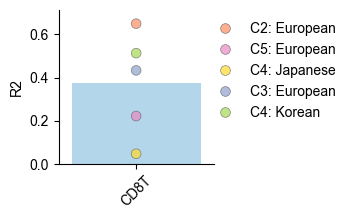

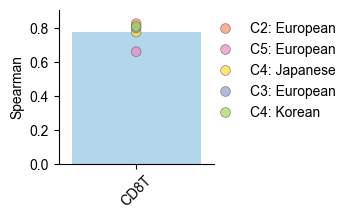

In [5]:
cv_scores_store = []
for cell_type in cell_types:
    scores_df = pd.read_csv(f"{temp_dir}/{cell_type}_{data_type}_{feature_type}_{reg_type}_cv_scores.csv", 
                            index_col=0)
    mask = scores_df<0
    scores_df[mask] = 0
    scores_df['cell_type'] = cell_type
    cv_scores_store.append(scores_df)
cv_scores = pd.concat(cv_scores_store, axis=0)
# - plot


# Ensure dataset name is a column
cv_scores = cv_scores.reset_index().rename(columns={'index': 'dataset'})

def plot_cv_scores(cv_scores, metric, figsize=[2.5, 2]):
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Strip plot (scatter of individual fold scores)
    sns.stripplot(
        data=cv_scores, x='cell_type', y=metric,
        hue='dataset', dodge=False, jitter=False, s=7,
        alpha=0.7, linewidth=0.5, edgecolor='gray', palette=palette_datasets_pretty,
        ax=ax
    )

    # Bar plot (mean scores per cell type)
    sns.barplot(
        data=cv_scores, x='cell_type', y=metric,
        estimator='mean', errorbar=None,
        color=colors_blind[1], alpha=0.5, ax=ax
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.margins(x=0.1, y=0.1)
    ax.spines[['top', 'right']].set_visible(False)
    # Legend
    ax.legend(title='', bbox_to_anchor=(.9, 1), loc='upper left', frameon=False)
    # Set axes properties
    ax.set(
        # title=f'{metric.upper()}',
        ylabel=metric.capitalize(),
        xlabel=''
    )
    return fig

figsize=(2, 2)
# Plot R² and Spearman
cv_scores['dataset'] = cv_scores['dataset'].map(surrogate_names)
fig = plot_cv_scores(cv_scores, 'r2', figsize)
fig.savefig(f'{plots_dir}/cv_scores_r2.png', bbox_inches='tight', dpi=300, transparent=True)
fig = plot_cv_scores(cv_scores, 'spearman',figsize)
fig.savefig(f'{plots_dir}/cv_scores_spearman.png', bbox_inches='tight', dpi=300, transparent=True)

In [6]:
# scatter plot
prediction_store = []
for cell_type in cell_types:
    predictions_df = pd.read_csv(f"{temp_dir}/{cell_type}_{data_type}_{feature_type}_{reg_type}_cv_predictions.csv")
    predictions_df['cell_type'] = cell_type
    prediction_store.append(predictions_df)
prediction_df = pd.concat(prediction_store, axis=0)
prediction_df

,Unnamed: 0,age,predicted_age,dataset,fold,cell_type
0,626,30,47.775367,data7_allTPs_jalil,0,CD8T
1,627,31,45.032067,data7_allTPs_jalil,0,CD8T
2,628,27,39.599211,data7_allTPs_jalil,0,CD8T
3,629,29,49.766844,data7_allTPs_jalil,0,CD8T
4,630,33,43.050162,data7_allTPs_jalil,0,CD8T
...,...,...,...,...,...,...
726,489,49,44.949972,data13_Korean,4,CD8T
727,491,24,16.507043,data13_Korean,4,CD8T
728,492,50,55.159939,data13_Korean,4,CD8T
729,493,26,35.120495,data13_Korean,4,CD8T


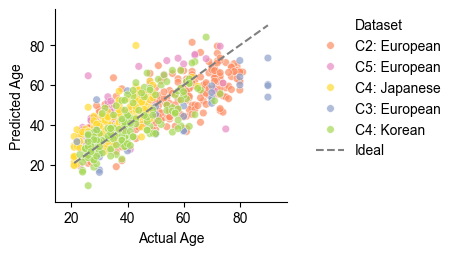

In [7]:
prediction_df['dataset'] = prediction_df['dataset'].apply(lambda name: surrogate_names.get(name, name))

for cell_type in ['CD8T']:
    fig, ax = plt.subplots(1, 1, figsize=(3, 2.5), sharey=True)

    df = prediction_df[prediction_df['cell_type'] == cell_type]

    plot_scatter_age_vs_predictedAge(df, dataset='', ax=ax, hue='dataset', palette=palette_datasets_pretty, s=30, alpha=0.7)
    ax.legend(loc=(1.1, .2), frameon=False, title='Dataset')
    plt.savefig(f'{plots_dir}/clock_training_datasets.png', bbox_inches='tight', dpi=300, transparent=True)

## Evaluate latent space

In [8]:
from ciim.src.clock.NN.helper import wrapper_get_latent 
cell_type='CD8T'
dataset=datasets_all[1]
adata = retrieve_adata_bulk(dataset=dataset, cell_type=cell_type)
adata = wrapper_get_latent(adata, batch_idx=None, reg_type='NN', cell_type=cell_type, data_type=data_type, feature_type=feature_type, version=version)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//clock/CD8T_bulk_gene_expression_NN_all_data_model.pt'

In [106]:
sc.pp.neighbors(adata, use_rep='VAE_latent', n_neighbors=10)
sc.tl.umap(adata)

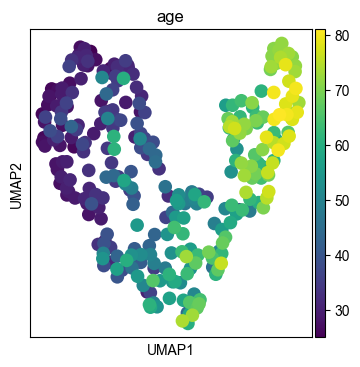

In [107]:
sc.pl.umap(adata, color='age')

## Run details

In [9]:
if reg_type == 'NN':
    loss = np.load(f'{temp_dir}/loss.npy')
    plt.plot(loss)
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training Loss over Epochs')
    plt.grid(True)
    plt.show()
if reg_type == 'NN':
    from ciim.src.clock.helper import evaluate_groupwise_median
    for cell_type in cell_types:
        adata_all = ad.read_h5ad(f"{temp_dir}/{cell_type}_{data_type}_{feature_type}_{reg_type}_adata.h5ad")
        obs = adata_all.obs.copy()
        obs['sex'] = obs['sex'].astype(str)
        obs['donor_age'] = obs['donor_age'].astype(str)
        obs['age'] = obs['age'].astype(float)
        obs['predicted_age'] = obs['predicted_age'].astype(float)
        datasets = obs['dataset'].unique()
        fig, axes = plt.subplots(1, len(datasets), figsize=(4*len(datasets), 3))
        i = 0
        for dataset in datasets:
            ax = axes[i] if len(datasets) > 1 else axes
            obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()
            obs_d = obs_d.groupby(['donor_age', 'age', 'sex'])['predicted_age'].median().reset_index()
            sns.scatterplot(data=obs_d, x='age', y='predicted_age', s=50, alpha=0.7, ax=ax, palette=palette_genders, hue='sex')
            min_age, max_age = obs_d['age'].min(), obs_d['age'].max()
            ax.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

            ax.set_xlabel("Actual Age")
            ax.set_ylabel("Predicted Age")

            spearman = evaluate_groupwise_median(obs_d)['Spearman']
            ax.set_title(f"{surrogate_names[dataset]} (Spearman:{spearman:.2f})")

            i+=1
            ax.get_legend().remove()
        ax.legend(loc=(1.1, .2), frameon=False, title='Gender')

        plt.suptitle(cell_type, fontsize=12, weight='bold')
        plt.tight_layout()

#  Compare to wenchao's results

In [10]:
W_train_datasets = ['data1', 'data7_allTPs_jalil'] # we only use these datasets for training for a fair comparision
test_datasets = ['SLE_European', 'data13_Korean']

version = 'comparitive'

In [11]:
if True:
    import subprocess

    cmd = [
        "python", "../src/clock/script.py",
        "--cell_types", *cell_types,
        "--datasets_training", *W_train_datasets,
        "--feature_type", feature_type,
        "--data_type", data_type,
        "--reg_type", reg_type,
        "--version", version,
        "--temp_dir", temp_dir,
        "--age_limit", "20"

    ]
    if tune_model:
        cmd += ["--tune_model"]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

Running: python ../src/clock/script.py --cell_types CD8T --datasets_training data1 data7_allTPs_jalil --feature_type gene_expression --data_type bulk --reg_type ridge --version comparitive --temp_dir /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//temp/ --age_limit 20 --tune_model
{'cell_types': ['CD8T'], 'datasets_training': ['data1', 'data7_allTPs_jalil'], 'feature_type': 'gene_expression', 'data_type': 'bulk', 'reg_type': 'ridge', 'tune_model': True, 'version': 'comparitive', 'temp_dir': '/Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//temp/', 'age_limit': 20}
building model for cell type: CD8T
(1285, 2042) (1285,)


Best trial: 19. Best value: 0.522195: 100%|██████████| 30/30 [00:00<00:00, 30.15it/s]



 Best alpha: 488.9002, Best CV performance: 0.5222


## Get W results on test data

In [12]:
def extract_w_results():
    # - read the results of predictions
    df_store = []
    for dataset in ['C4', 'C5']:
        df = pd.read_csv(f'{base_dir}/clock/wenchao/val_data_majorCT_Wenchao_AC_{dataset}_predicted_age_donor.tsv', sep='\t')
        df['dataset'] = 'data13_Korean' if dataset=='C4' else 'SLE_European'
        df_store.append(df)
    df = pd.concat(df_store, axis=0)
    df['donor_age'] = df['donor_id'].astype(str) + '_' + df['age'].astype(str)
    # - format 
    df.rename(columns={'Prediction': 'predicted_age', 'CT': 'cell_type'}, inplace=True)
    df['sex'] = df['sex'].map({'M': 'Male', 'F': 'Female'})
    # - median prediction
    median_prediction = df.groupby(['cell_type', 'donor_age', 'dataset'])['predicted_age'].median().reset_index()
    median_prediction = df[['cell_type', 'donor_age', 'age', 'sex', 'dataset']].drop_duplicates().merge(median_prediction, on=['cell_type', 'donor_age', 'dataset'], how='left')
    return median_prediction
W_median_prediction = extract_w_results()

## Get our results on test data

In [13]:
predictions_all = get_all_predictions(cell_types, test_datasets, version=version)
predictions_all.head()

,age,predicted_age,donor_age,dataset,cell_type,condition
298,39,87.194977,100439,SLE_European,CD8T,SLE
299,40,99.613408,101440,SLE_European,CD8T,SLE
300,54,101.048002,101554,SLE_European,CD8T,SLE
301,64,96.557915,101964,SLE_European,CD8T,SLE
302,42,89.547846,103942,SLE_European,CD8T,SLE


In [14]:
from ciim.src.clock.helper import evaluate_groupwise_median
test_predictions = predictions_all[(predictions_all['dataset'].isin(test_datasets)) & (predictions_all['condition']=='Healthy')]
test_predictions.head()

,age,predicted_age,donor_age,dataset,cell_type,condition
374,27,75.353723,HC-00227,SLE_European,CD8T,Healthy
375,53,104.830637,HC-00653,SLE_European,CD8T,Healthy
376,48,102.491070,HC-00848,SLE_European,CD8T,Healthy
377,27,63.557897,HC-00927,SLE_European,CD8T,Healthy
378,35,85.749737,HC-02035,SLE_European,CD8T,Healthy


In [15]:
test_predictions['dataset'].unique()

array(['SLE_European', 'data13_Korean'], dtype=object)

## Calculate the scores

In [16]:
import pandas as pd

all_scores = []

for cell_type in test_predictions['cell_type'].unique():
    for dataset in test_datasets:
        # Your model
        df1 = test_predictions[
            (test_predictions['dataset'] == dataset) & 
            (test_predictions['cell_type'] == cell_type)
        ].copy()
        ss1 = evaluate_groupwise_median(df1)  # returns {'Spearman': ..., 'R2': ...}
        all_scores.append({
            'dataset': dataset,
            'cell_type': cell_type,
            'model': 'GRNdrived',
            'Spearman': ss1['Spearman'],
            'R2': ss1['R2']
        })

        # Wenchao's model
        df2 = W_median_prediction[
            (W_median_prediction['dataset'] == dataset) & 
            (W_median_prediction['cell_type'] == cell_type)
        ].copy()
        ss2 = evaluate_groupwise_median(df2)
        all_scores.append({
            'dataset': dataset,
            'cell_type': cell_type,
            'model': 'Wenchao',
            'Spearman': ss2['Spearman'],
            'R2': ss2['R2']
        })

# Convert to DataFrame
score_df = pd.DataFrame(all_scores)


## Plot

In [17]:
palette_models = {
    'Wenchao': colors_blind[1], 
    'GRNdrived': colors_blind[0]
}

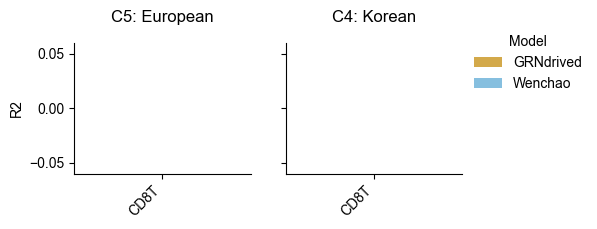

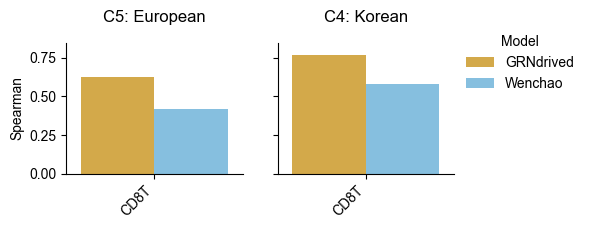

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clip R2 to [0, 1]
score_df['R2'] = score_df['R2'].clip(0, 1)

# Sort datasets for consistent layout
datasets = score_df['dataset'].unique()
n_datasets = len(datasets)

# Plot each metric in a separate figure
for metric in ['R2', 'Spearman']:
    fig, axes = plt.subplots(1, n_datasets, figsize=(2.5 * n_datasets, 1.7), sharey=True)

    if n_datasets == 1:
        axes = [axes]  # Ensure iterable if only one axis

    for ax, dataset in zip(axes, datasets):
        df_plot = score_df[score_df['dataset'] == dataset]

        sns.barplot(
            data=df_plot,
            x='cell_type',
            y=metric,
            hue='model',
            ax=ax,
            alpha=0.8,
            palette=palette_models,
        )   

        ax.set_ylabel(metric)
        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.margins(x=0.1, y=0.1)
        ax.spines[['top', 'right']].set_visible(False)
        ax.get_legend().remove()
        ax.set_title(f'{surrogate_names[dataset]}', pad=15)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Model', bbox_to_anchor=(.9, 1), loc='upper left', frameon=False)
    # fig.tight_layout()
    plt.savefig(f'{plots_dir}/clock_comparison_{metric}.png', bbox_inches='tight', dpi=300, transparent=True)


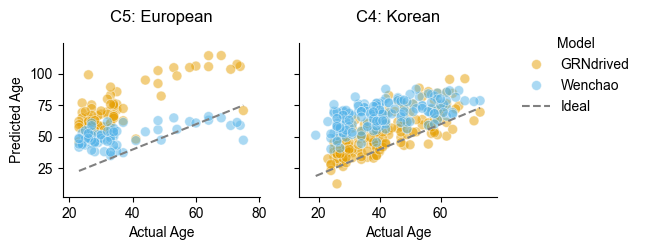

In [19]:
W_median_prediction['model'] = 'Wenchao'
test_predictions['model'] = 'GRNdrived'

obs = pd.concat([test_predictions, W_median_prediction], axis=0)
datasets = obs['dataset'].unique()

for cell_type in ['CD8T']:
    fig, axes = plt.subplots(1, len(datasets), figsize=(2.8*len(datasets), 2), sharey=True)
    i = 0
    for dataset in datasets:
        ax = axes[i] if len(datasets) > 1 else axes
        obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()

        plot_scatter_age_vs_predictedAge(obs_d, dataset=dataset, ax=ax, hue='model', palette=palette_models)
        i+=1
        ax.get_legend().remove()
    ax.legend(loc=(1.1, .5), frameon=False, title='Model')
    plt.savefig(f'{plots_dir}/clock_comparison_{cell_type}.png', bbox_inches='tight', dpi=300, transparent=True)
    
    # plt.suptitle(cell_type, fontsize=12, weight='bold')
    # plt.tight_layout()

# Performance on disease

In [22]:
obs = get_all_predictions(cell_types, datasets_disease)

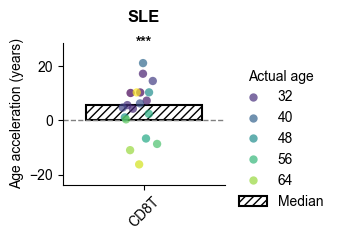

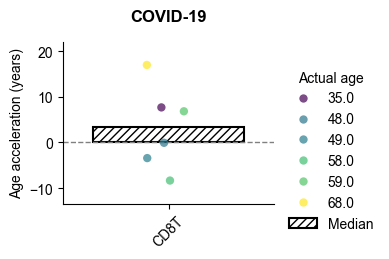

In [23]:
from ciim.src.clock.plots import wrapper_age_acceleration_disease, wrapper_age_acceleration_disease

# Call the function
wrapper_age_acceleration_disease(obs[obs['cell_type'].isin(['CD8T', 'CD4T'])], disease_dataset='SLE_European', figsize=(3.5, 2.5))
plt.savefig(f'{plots_dir}/clock_SLE.png', bbox_inches='tight', dpi=300, transparent=True)
wrapper_age_acceleration_disease(obs, disease_dataset='Covid_50MHH')

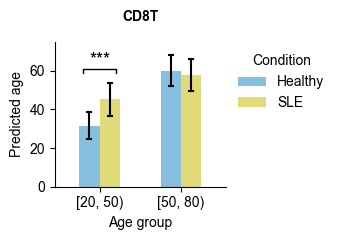

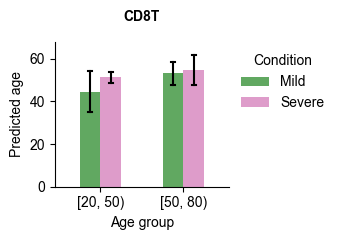

In [ ]:
from ciim.src.clock.plots import wrapper_plot_age_acceleration_disease_bins

# Example usage (make sure n_cell_types, cell_types, and surrogate_names are defined)
wrapper_plot_age_acceleration_disease_bins(obs[obs['cell_type']=='CD8T'], disease_dataset='SLE_European')
plt.savefig(f'{plots_dir}/clock_SLE_bins_cd8t.png', bbox_inches='tight', dpi=300, transparent=True)

aa = wrapper_plot_age_acceleration_disease_bins(obs, disease_dataset='SLE_European')
plt.savefig(f'{plots_dir}/clock_SLE_bins.png', bbox_inches='tight', dpi=300, transparent=True)
aa = wrapper_plot_age_acceleration_disease_bins(obs, disease_dataset='Covid_50MHH')

# Perturbation

In [28]:
dataset = 'pbmc_cytokine' #'CXCL9' # 'op'

if dataset == 'op':
    test_type='mixed_effect'
    covariates = ['plate_name', 'row']
    p_value_t = 0.001  # significance threshold
elif dataset == 'CXCL9':
    test_type='paired'
    covariates = []
    p_value_t = .05  # significance threshold
elif dataset == 'pbmc_cytokine':
    test_type='mixed_effect'
    covariates = ['cell_type_minor']
    p_value_t = .05
# covariates=['cell_type_minor', 'well']
obs_drug =  get_all_predictions(cell_types, [dataset], covariates=covariates)

# Always include 'donor_age' as part of the test_group
grouping_vars = ['donor_age'] + covariates

# Ensure all are string before joining
obs_drug['test_group'] = obs_drug[grouping_vars].astype(str).agg('_'.join, axis=1)

In [36]:
obs_drug = obs_drug[obs_drug['cell_type_minor']=='CD8 Naive']

<Axes: >

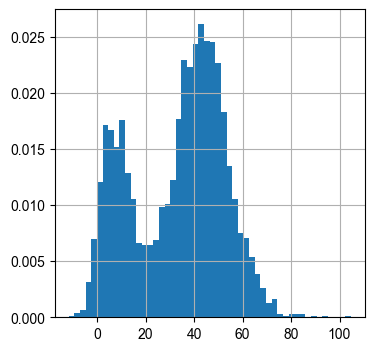

In [30]:
obs_drug['predicted_age'].hist(bins=50, density=True)

In [31]:
pretty_names = {
    '24 h LPS': 'LPS',
    '24 h LPS + metformin': 'Met.',
    # '24 h LPS + metformin + ruxolitinib': 'LPS / Met+Rux', #Ruxolitinib
    '24 h LPS + ruxolitinib': 'LPS+Rux.',
    '24 h RPMI': 'RPMI',
    '24 h RPMI + metformin': 'RPMI+Met',
    # '24 h RPMI + metformin + ruxolitinib': 'RPMI+Met+Rux',
    '24 h RPMI + ruxolitinib': 'RPMI+Rux',
    # '24 h RPMI': 'RPMI',
    # '24 h rhCXCL9': 'rhCXCL9',
    # '24 h rhIFN-γ': 'rhIFN-γ'
}
if dataset == 'CXCL9':
    experiments = [
                    # ('24 h RPMI', '24 h rhCXCL9'),
                    ('24 h RPMI', '24 h LPS'),
                    # ('24 h RPMI', '24 h rhIFN-γ'),
                    ('24 h RPMI', '24 h RPMI + metformin'),
                    ('24 h RPMI', '24 h RPMI + ruxolitinib'),
                    # ('24 h RPMI', '24 h RPMI + metformin + ruxolitinib'),
                    ('24 h LPS', '24 h LPS + metformin'),
                    ('24 h LPS', '24 h LPS + ruxolitinib'),
                    # ('24 h LPS', '24 h LPS + metformin + ruxolitinib'),
                    ]
elif dataset=='op':
    experiments = [('Dimethyl Sulfoxide', treatment) for treatment in obs_drug['condition'].unique() if treatment != 'Dimethyl Sulfoxide']
elif dataset=='pbmc_cytokine':
    ctr = 'PBS'
    experiments = [(ctr, treatment) for treatment in obs_drug['condition'].unique() if treatment != ctr]
else:
    raise ValueError(f"Dataset {dataset} not recognized for drug perturbation experiments.")
n_exp = len(experiments)

### Only sig ones

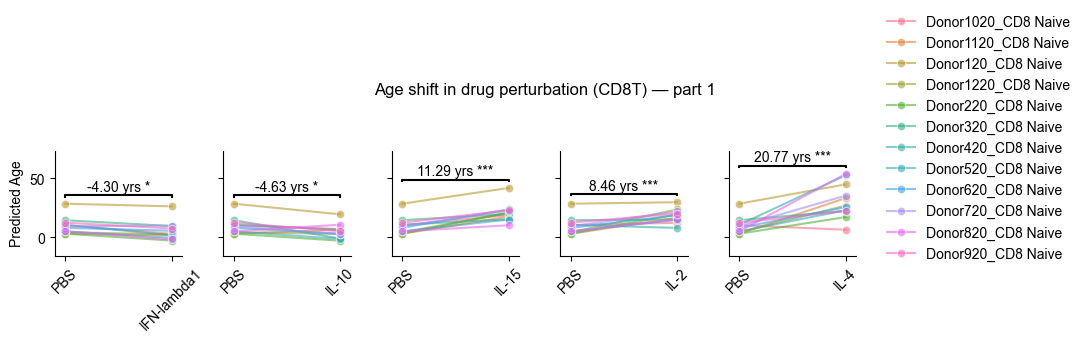

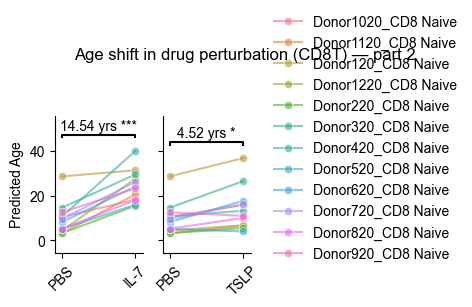

In [39]:

def plot_paired_experiment(df_all, ctr, treatment, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 2.5))
    df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
    df_pivot = df_sub.pivot_table(index='test_group', columns='condition', values='predicted_age')
    # df_pivot['test_group'] = ['Donor ' + str(i+1) for i, d in enumerate(df_pivot.index)]
    # df_pivot.set_index('test_group', inplace=True)
    df_pivot = df_pivot.dropna(subset=[ctr, treatment], how='any')

    unique_donors = df_pivot.index.unique()
    donor_palette = dict(zip(unique_donors, sns.color_palette("husl", len(unique_donors))))

    df_plot = df_pivot.reset_index().melt(
        id_vars='test_group', 
        value_vars=[ctr, treatment], 
        var_name='condition', 
        value_name='predicted_age'
    )
    # df_plot['condition'] = df_plot['condition'].map(pretty_names)

    sns.lineplot(
        data=df_plot,
        x='condition', y='predicted_age',
        hue='test_group', marker='o', alpha=0.6,
        ax=ax, palette=donor_palette, legend=True
    )

    # Get p-value and slope
    pval, slope = pval_map.get((cell_type, ctr, treatment), (1.0, 0))
    star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''

    # Draw significance bracket
    y_max = df_plot['predicted_age'].max()
    h = 1  # height of bracket
    y_bracket = y_max + 7

    ax.plot([0, 0, 1, 1], [y_bracket - h, y_bracket, y_bracket, y_bracket - h],
            lw=1.5, c='black')
    ax.text(0.5, y_bracket + 1, f"{slope:.2f} yrs {star}", ha='center', va='bottom', fontsize=10)

    ax.set_title("")  # No text in title
    ax.set_xlabel("")
    ax.set_ylabel("Predicted Age")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.margins(x=0.1, y=0.2)
    ax.get_legend().remove()
    ax.spines[['top', 'right']].set_visible(False)

    ax.legend(loc=(1.2, -.1), frameon=False)

import math

for cell_type in cell_types:
    df_all = obs_drug[obs_drug['cell_type'] == cell_type][['test_group', 'condition', 'predicted_age']].copy()

    significant_experiments = [
        (ctr, treatment) for (ctr, treatment) in experiments
        if pval_map.get((cell_type, ctr, treatment), (1.0, 0))[0] < p_value_t
    ]
    if not significant_experiments:
        continue

    max_per_fig = 5
    n = len(significant_experiments)
    chunks = [significant_experiments[i:i + max_per_fig] for i in range(0, n, max_per_fig)]

    for chunk_idx, chunk in enumerate(chunks):
        fig, axes = plt.subplots(1, len(chunk), figsize=(2 * len(chunk) + 1, 2.7), sharey=True)
        if len(chunk) == 1:
            axes = [axes]

        for i, (ctr, treatment) in enumerate(chunk):
            ax = axes[i]
            plot_paired_experiment(df_all, ctr, treatment, ax=ax)
            ax.get_legend().remove()

        ax.legend(loc=(1.2, -.1), frameon=False)
        fig.suptitle(f'Age shift in drug perturbation ({cell_type}) — part {chunk_idx + 1}', fontsize=12, weight='bold')
        fig.tight_layout()

In [42]:
if False:
    print(df_all['condition'].unique())
    df_all = obs_drug[obs_drug['cell_type'] == 'CD4T'][['test_group', 'condition', 'predicted_age']].copy()

    # plot_paired_experiment(df_all, ctr='Dimethyl Sulfoxide', treatment='24h + Ruxolitinib')
    plot_paired_experiment(df_all, ctr='24 h LPS', treatment='24 h LPS + ruxolitinib')

In [ ]:
if False:
    # - mixed effect model
    import statsmodels.formula.api as smf
    for cell_type in obs_drug['cell_type'].unique():
        obs_drug_t = obs_drug[obs_drug['cell_type'] == cell_type].copy()
        model = smf.mixedlm("predicted_age ~ condition + plate_name + row", obs_drug_t, groups=obs_drug_t["donor_age"])
        result = model.fit()

        from statsmodels.stats.multitest import multipletests

        # Adjust p-values using Benjamini-Hochberg (FDR)
        adjusted_pvals = multipletests(result.pvalues, method='fdr_bh')[1]

        # Add to summary
        summary = pd.DataFrame({
            "coef": result.params,
            "pval": result.pvalues,
            "adj_pval": adjusted_pvals
        })

        # Filter by adjusted p-value
        sig_summary = summary[summary["adj_pval"] < 0.05]
        print(sig_summary.sort_values(by='adj_pval'))